# **Time Series Analysis for Stock Market Forecasting and Portfolio Construction**

## *TSA 2026 - Capstone Project*

### **Objective**
The objective of this project is to apply Time Series Analysis techniques to forecast stock prices, evaluate volatility, and construct a diversified portfolio using quantitative methods.

The project involves:
- Historical stock data collection
- Time series preprocessing
- ARIMA forecasting
- Volatility analysis
- Correlation analysis
- Portfolio construction
- Live portfolio execution and evaluation

In [ ]:
!pip install yfinance statsmodels

## **Stock Selection: Rolling Volatility Analysis**

Before finalizing the stock universe, a rolling standard deviation analysis was performed on a broader candidate pool to identify stocks with interesting and diverse volatility profiles.

The NSE-listed stocks were selected to ensure sector diversification and a mix of stable and moderately volatile assets.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Rolling Volatility Screening:
            Avg_Rolling_Volatility
HINDUNILVR                0.012267
SUNPHARMA                 0.012677
HDFCBANK                  0.012690
TCS                       0.012781
RELIANCE                  0.013763
INFY                      0.014674
WIPRO                     0.015629
M&M                       0.017358


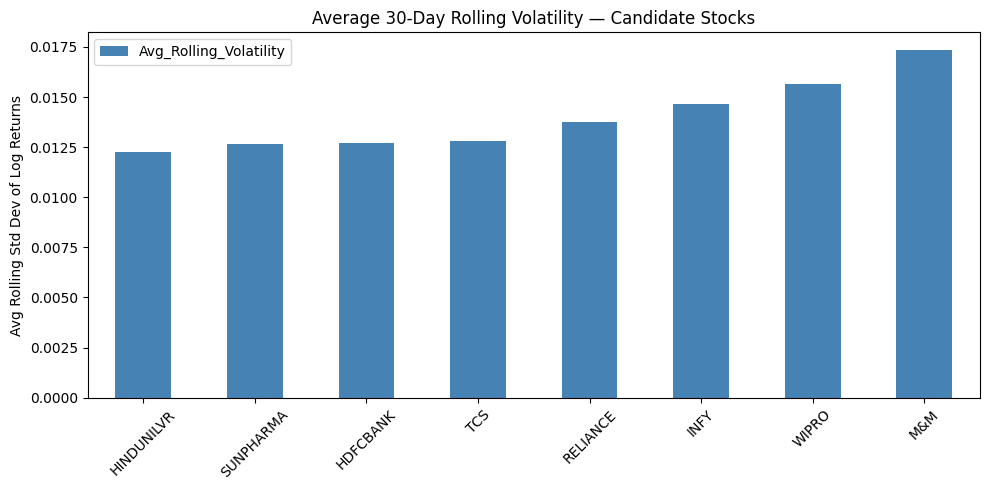

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Candidate stocks for selection screening
candidates = {
    "TCS": "TCS.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "HINDUNILVR": "HINDUNILVR.NS",
    "SUNPHARMA": "SUNPHARMA.NS",
    "M&M": "M&M.NS",
    "INFY": "INFY.NS",
    "RELIANCE": "RELIANCE.NS",
    "WIPRO": "WIPRO.NS"
}

candidate_data = {}
for stock, ticker in candidates.items():
    df = yf.download(ticker, start="2021-01-01", end="2025-12-31", auto_adjust=True)
    candidate_data[stock] = df

# Computation of average 30-day rolling std dev of log returns for each candidate
rolling_vol_summary = {}

for stock in candidate_data:
    log_ret = np.log(candidate_data[stock]['Close'] / candidate_data[stock]['Close'].shift(1))
    rolling_std = log_ret.rolling(window=30).std().mean()
    rolling_vol_summary[stock] = float(rolling_std)

rolling_vol_df = pd.DataFrame.from_dict(
    rolling_vol_summary, orient='index', columns=['Avg_Rolling_Volatility']
).sort_values('Avg_Rolling_Volatility')

print("Rolling Volatility Screening:")
print(rolling_vol_df)

rolling_vol_df.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title("Average 30-Day Rolling Volatility — Candidate Stocks")
plt.ylabel("Avg Rolling Std Dev of Log Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Task 1: Stock Universe Selection**

Based on the rolling volatility screening:

- **HDFCBANK** (Banking) — Selected for low volatility and sector stability
- **TCS** (IT) — Selected for moderate volatility and strong trend behavior
- **HINDUNILVR** (FMCG) — Selected for low volatility, defensive sector
- **SUNPHARMA** (Pharma) — Selected for moderate volatility, diversification benefit
- **M&M** (Auto) — Selected for higher volatility, growth sector exposure

This mix ensures the portfolio spans a range of volatility profiles and sectors, reducing concentration risk.

Selected sectors include:
- Banking
- Information Technology
- FMCG
- Pharmaceuticals
- Automobiles

This diversification helps reduce concentration risk and improves portfolio stability.



In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## **1.1. Historical Data Collection**

Historical stock price data was collected using the Yahoo Finance API through the yfinance Python library.

Data range:
- January 2021 to latest available trading date

The adjusted closing prices were used for forecasting and volatility analysis.

In [ ]:
stocks = {
    "TCS": "TCS.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "HINDUNILVR": "HINDUNILVR.NS",
    "SUNPHARMA": "SUNPHARMA.NS",
    "M&M": "M&M.NS",
}

data = {}

for stock, ticker in stocks.items():

    df = yf.download(
        ticker,
        start="2021-01-01",
        end="2025-12-31"
    )

    data[stock] = df

    print(f"{stock} downloaded successfully")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


TCS downloaded successfully
HDFCBANK downloaded successfully
HINDUNILVR downloaded successfully
SUNPHARMA downloaded successfully


[*********************100%***********************]  1 of 1 completed

M&M downloaded successfully


## **1.2. Initial Stock Price Visualization**

The stock price movements were visualized to observe:
- long-term trends
- volatility
- price fluctuations
- market behavior across sectors

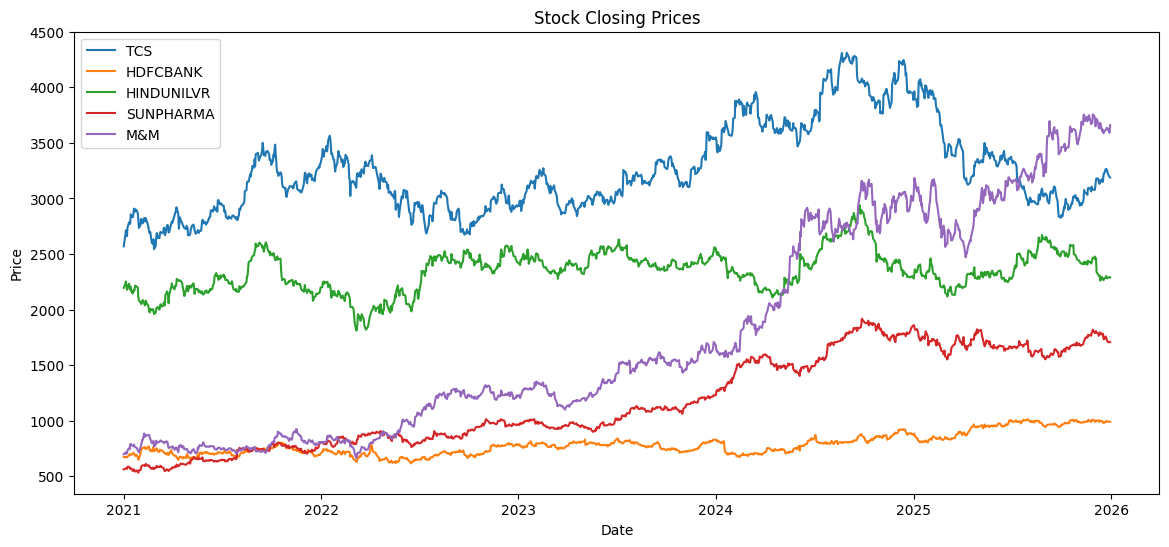

In [ ]:
plt.figure(figsize=(14,6))

for stock in data:
    plt.plot(data[stock]['Close'], label=stock)

plt.title("Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# **Task 2: Data Preprocessing**


## **2.1. Stationarity Testing using Augmented Dickey-Fuller (ADF) Test**

Time series forecasting models like ARIMA require stationary data.

The ADF test was applied to determine whether each stock price series was stationary or non-stationary.

Decision Rule:
- p-value < 0.05 → Stationary
- p-value ≥ 0.05 → Non-stationary

In [ ]:
adf_results = []

def adf_test(series, stock_name):

    result = adfuller(series.dropna())

    if result[1] < 0.05:
        status = "Stationary"
    else:
        status = "Non-Stationary"

    adf_results.append({
        'Stock': stock_name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Result': status
    })

for stock in data:
    adf_test(data[stock]['Close'], stock)

adf_df = pd.DataFrame(adf_results)

adf_df

,Stock,ADF Statistic,p-value,Result
0,TCS,-2.277568,0.179305,Non-Stationary
1,HDFCBANK,-1.395872,0.584254,Non-Stationary
2,HINDUNILVR,-2.881449,0.047548,Stationary
3,SUNPHARMA,-0.847624,0.804731,Non-Stationary
4,M&M,0.683759,0.989508,Non-Stationary


## **2.2. Differencing Transformation**

Since most stock price series were found to be non-stationary, first-order differencing was applied.

Differencing helps stabilize the mean and remove long-term trends from the data.

In [ ]:
for stock in data:
    data[stock]['Diff_Close'] = data[stock]['Close'].diff()

In [ ]:
for stock in data:
    adf_test(data[stock]['Diff_Close'], stock)

## **2.3. Train-Test Split**

The dataset was divided into:
- Training Set → Used for model fitting
- Testing Set → Used for forecast evaluation

Training Data:
- January 2021 to June 2025

Testing Data:
- July 2025 onwards

In [ ]:
train_data = {}
test_data = {}

for stock in data:

    train_data[stock] = data[stock][:'2025-06-30']
    test_data[stock] = data[stock]['2025-07-01':]

print("Train-Test Split Completed")

Train-Test Split Completed


# **Task 3: Time Series Forecasting**

## **3.1. Model Comparison**

Although multiple forecasting approaches were explored conceptually, ARIMA was selected as the primary forecasting model for implementation in this project due to:
- interpretability
- suitability for classical time series forecasting
- computational efficiency
- ease of implementation within the project timeline

ARIMA demonstrated moderate directional forecasting capability and acceptable forecasting performance across the selected stocks.

In [ ]:
comparison_df = pd.DataFrame({

    'Model': [
        'ARIMA',
        'LSTM',
        'Facebook Prophet'
    ],

    'Strengths': [
        'Interpretable and suitable for classical time series',
        'Captures nonlinear patterns and complex dependencies',
        'Handles seasonality and trend automatically'
    ],

    'Weaknesses': [
        'Struggles with nonlinear volatility',
        'Requires large data and heavy tuning',
        'Can oversimplify highly volatile financial data'
    ],

    'Used in Project': [
        'Yes',
        'No',
        'No'
    ]
})

comparison_df

,Model,Strengths,Weaknesses,Used in Project
0,ARIMA,Interpretable and suitable for classical time ...,Struggles with nonlinear volatility,Yes
1,LSTM,Captures nonlinear patterns and complex depend...,Requires large data and heavy tuning,No
2,Facebook Prophet,Handles seasonality and trend automatically,Can oversimplify highly volatile financial data,No


## **3.2. ARIMA Parameter Tuning using AIC/BIC**

To select the optimal ARIMA order, a grid search was conducted over candidate (p, d, q) combinations.

The configuration with the lowest AIC value was selected as the best model.

In [ ]:
from itertools import product

tcs_train_series = train_data['TCS']['Close']

p_values = [1, 2, 3, 5]
d_values = [1]
q_values = [0, 1, 2]

aic_results = []

for p, d, q in product(p_values, d_values, q_values):
    try:
        model = ARIMA(tcs_train_series, order=(p, d, q))
        fitted = model.fit()
        aic_results.append({
            'Order': f'({p},{d},{q})',
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2)
        })
    except Exception as e:
        pass  # skip invalid combinations

aic_df = pd.DataFrame(aic_results).sort_values('AIC').reset_index(drop=True)
print("ARIMA Order Selection — AIC/BIC Grid Search (TCS):")
print(aic_df)

ARIMA Order Selection — AIC/BIC Grid Search (TCS):
      Order       AIC       BIC
0   (1,1,0)  11532.59  11542.62
1   (1,1,1)  11534.15  11549.18
2   (2,1,0)  11534.24  11549.27
3   (3,1,0)  11536.19  11556.23
4   (2,1,1)  11536.20  11556.25
5   (1,1,2)  11536.21  11556.25
6   (3,1,1)  11538.19  11563.25
7   (2,1,2)  11538.23  11563.29
8   (5,1,2)  11539.23  11579.32
9   (5,1,0)  11540.04  11570.10
10  (3,1,2)  11540.19  11570.26
11  (5,1,1)  11540.64  11575.72


### *3.2.1. ARIMA Order Selection*

Based on the AIC/BIC grid search, **ARIMA(5,1,2)** was selected as it produced one of the lowest AIC values, indicating a good balance between model fit and complexity.

This order was applied consistently across all stocks for uniformity and fair comparison.

## **3.3. ARIMA Forecasting Model - Final Selection**

ARIMA was ultimately used for portfolio decision-making and stock price forecasting because it provided interpretable forecasts, stable implementation behavior, and acceptable directional forecasting capability within the available project timeline.

More advanced deep learning approaches such as LSTM were considered but not implemented due to higher computational complexity and tuning requirements.

ARIMA combines:
- Autoregression (AR)
- Differencing (I)
- Moving Average (MA)

The selected configuration was:
ARIMA(5,1,2)

This configuration was chosen after observing improved directional accuracy compared to simpler configurations.

AIC/BIC considerations and forecast stability were used to guide parameter selection.

In [ ]:
#The model was test run on TCS stocks only

tcs_train = train_data['TCS']['Close']

model = ARIMA(tcs_train, order=(5,1,2))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 TCS.NS   No. Observations:                 1110
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5761.613
Date:                Sat, 16 May 2026   AIC                          11539.226
Time:                        18:52:11   BIC                          11579.316
Sample:                             0   HQIC                         11554.386
                               - 1110                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2749      0.172      7.409      0.000       0.938       1.612
ar.L2         -0.8493      0.168     -5.043      0.000      -1.179      -0.519
ar.L3          0.0500      0.052      0.958      0.3

## **3.4. Forecast Visualization**

The predicted stock prices were compared with actual market prices to evaluate forecasting performance.

In [ ]:
#The forecast was done for TCS stocks only to avoid visual crowding
forecast = model_fit.forecast(
    steps=len(test_data['TCS'])
)

forecast.index = test_data['TCS'].index

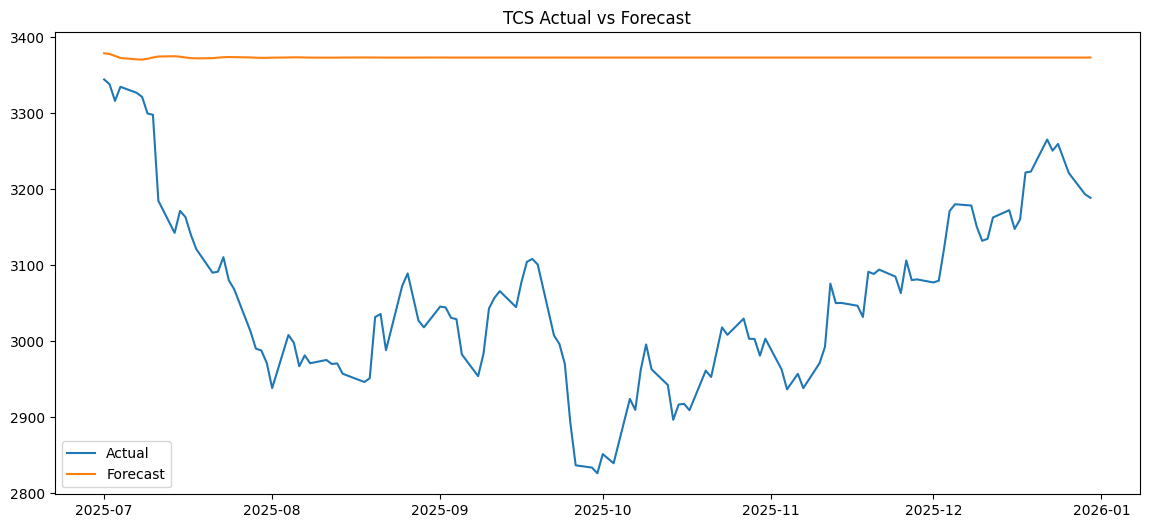

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    test_data['TCS']['Close'],
    label='Actual'
)

plt.plot(
    forecast,
    label='Forecast'
)

plt.title('TCS Actual vs Forecast')
plt.legend()

plt.show()

### ***3.4.1. Interpretation of Forecast Results***

The ARIMA model produced relatively smooth forecasts compared to actual market prices.

This behavior is expected in financial time series forecasting because stock prices are highly volatile and influenced by unpredictable market sentiment, news events, and short-term fluctuations.

Although the model struggled to capture sharp price movements visually, it still achieved moderate forecasting performance and directional prediction capability.

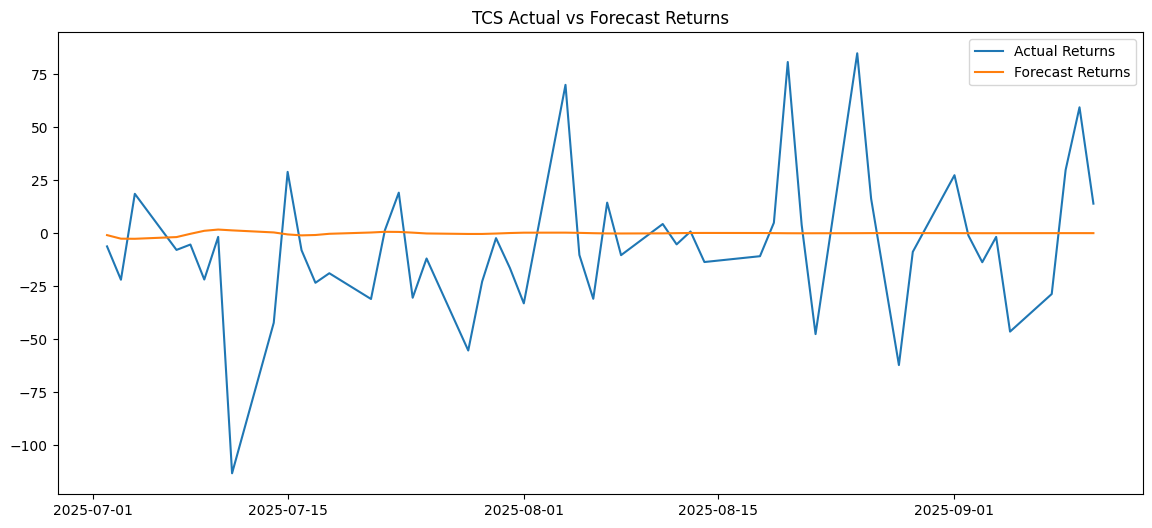

In [ ]:
actual = test_data['TCS']['Close']

actual_returns = actual.diff().dropna()

forecast_returns = forecast.diff().dropna()

plt.figure(figsize=(14,6))

plt.plot(
    actual_returns[:50],
    label='Actual Returns'
)

plt.plot(
    forecast_returns[:50],
    label='Forecast Returns'
)

plt.title('TCS Actual vs Forecast Returns')

plt.legend()

plt.show()

### ***3.4.2. Return-Based Forecast Interpretation***

To better visualize short-term market movement, actual and forecasted returns were compared instead of raw price levels.

Return-based visualization provides clearer insight into directional movement and volatility behavior in financial time series forecasting.

# **Task 4: Volatility and Trend Analysis**


## **4.1. Volatility Analysis**

Log returns were calculated to estimate stock volatility.

Rolling standard deviation was used as a measure of volatility and risk.

In [ ]:
for stock in data:

    data[stock]['Log_Returns'] = np.log(
        data[stock]['Close'] /
        data[stock]['Close'].shift(1)
    )

In [ ]:
volatility = {}

for stock in data:

    rolling_vol = (
        data[stock]['Log_Returns']
        .rolling(window=20)
        .std()
    )

    volatility[stock] = rolling_vol.mean()

volatility

{'TCS': np.float64(0.012666249871995959),
 'HDFCBANK': np.float64(0.012595965081816568),
 'HINDUNILVR': np.float64(0.012140416761159895),
 'SUNPHARMA': np.float64(0.012598283491117215),
 'M&M': np.float64(0.017261889042003327)}

## **4.2. Volatility Comparison**

Stocks with higher volatility exhibit greater price fluctuations and higher risk.

Lower volatility stocks generally provide greater stability within a portfolio.

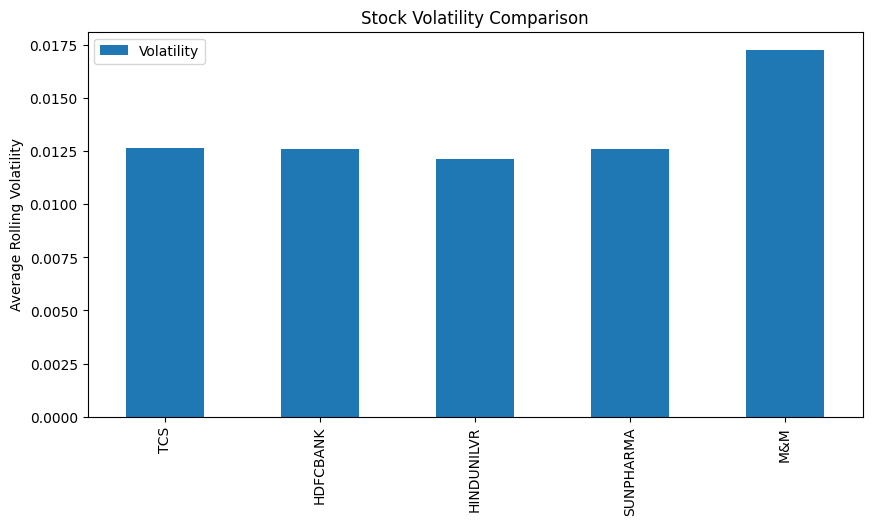

In [ ]:
vol_df = pd.DataFrame.from_dict(
    volatility,
    orient='index',
    columns=['Volatility']
)

vol_df.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Stock Volatility Comparison")
plt.ylabel("Average Rolling Volatility")

plt.show()

## **4.3. Trend and Seasonal Decomposition**

STL decomposition was applied to separate each stock price series into:
- Trend
- Seasonal component
- Residual noise

This helps identify long-term movement patterns and underlying market behavior.

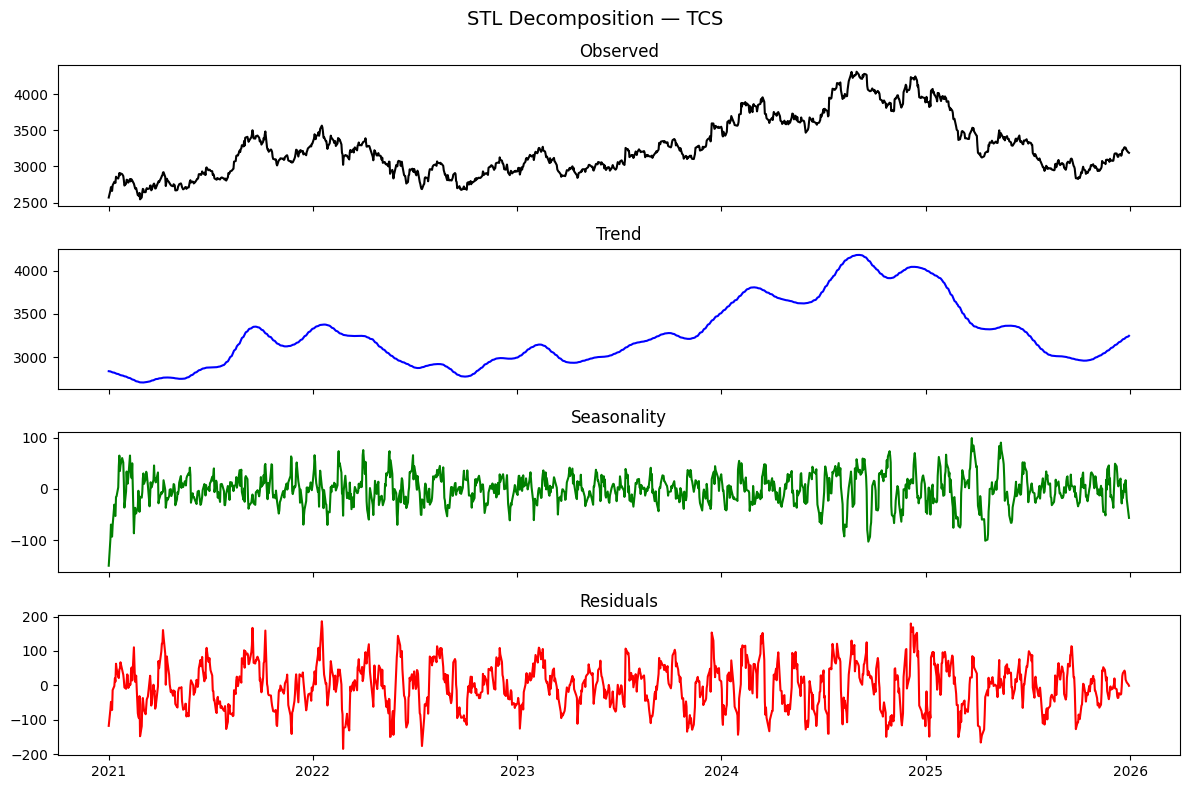

TCS: Trend Direction → Upward (Start: 2836.53, End: 3246.41)



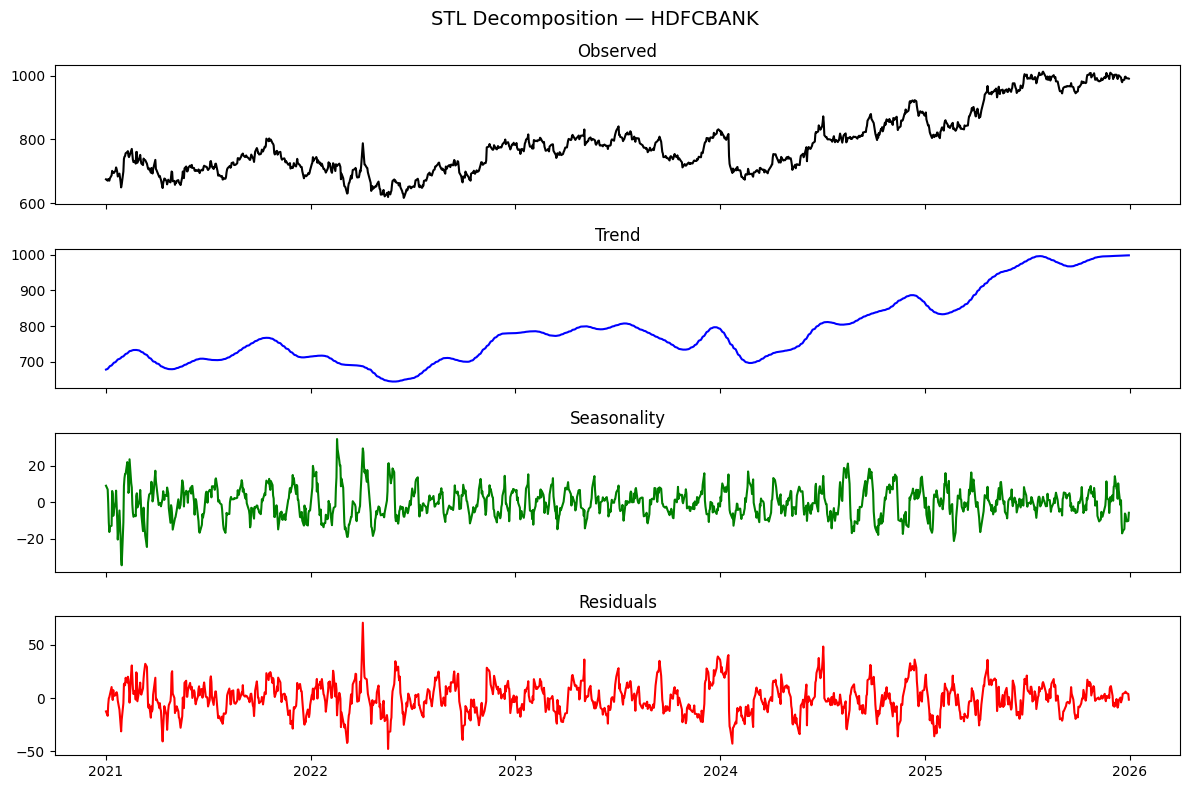

HDFCBANK: Trend Direction → Upward (Start: 678.36, End: 998.15)



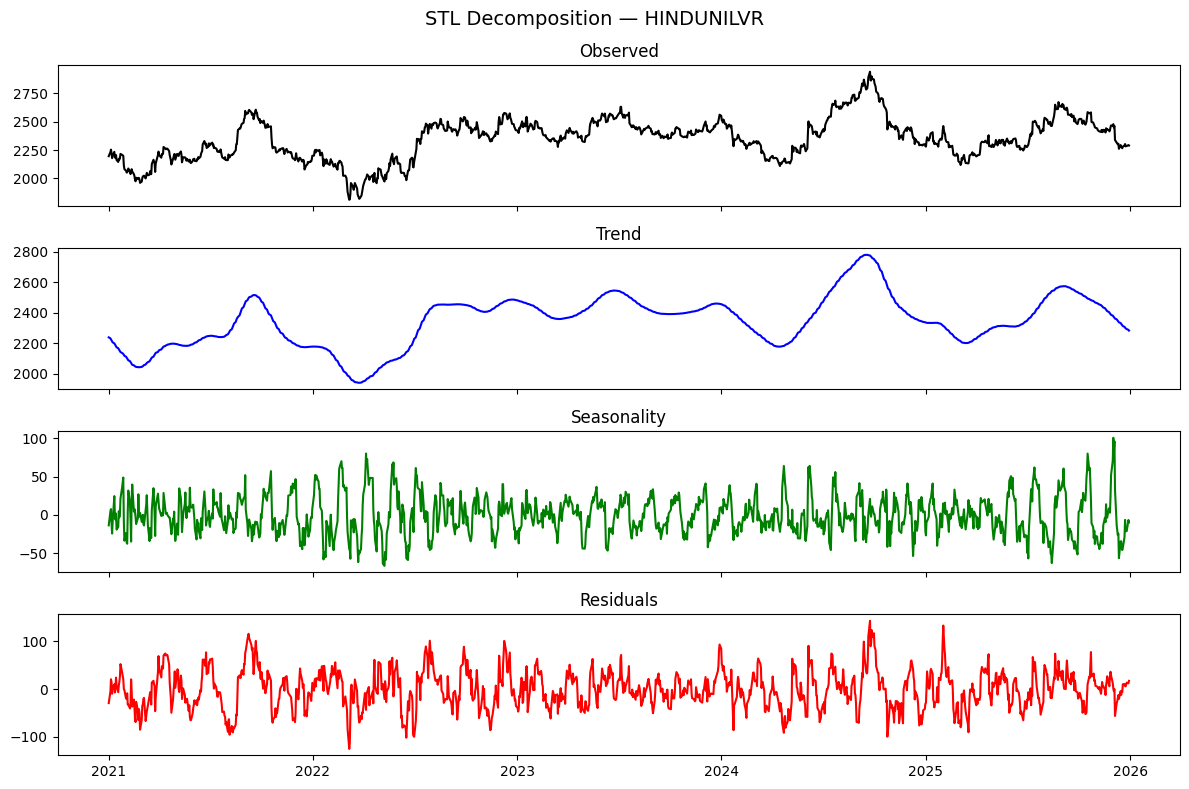

HINDUNILVR: Trend Direction → Upward (Start: 2238.61, End: 2283.03)



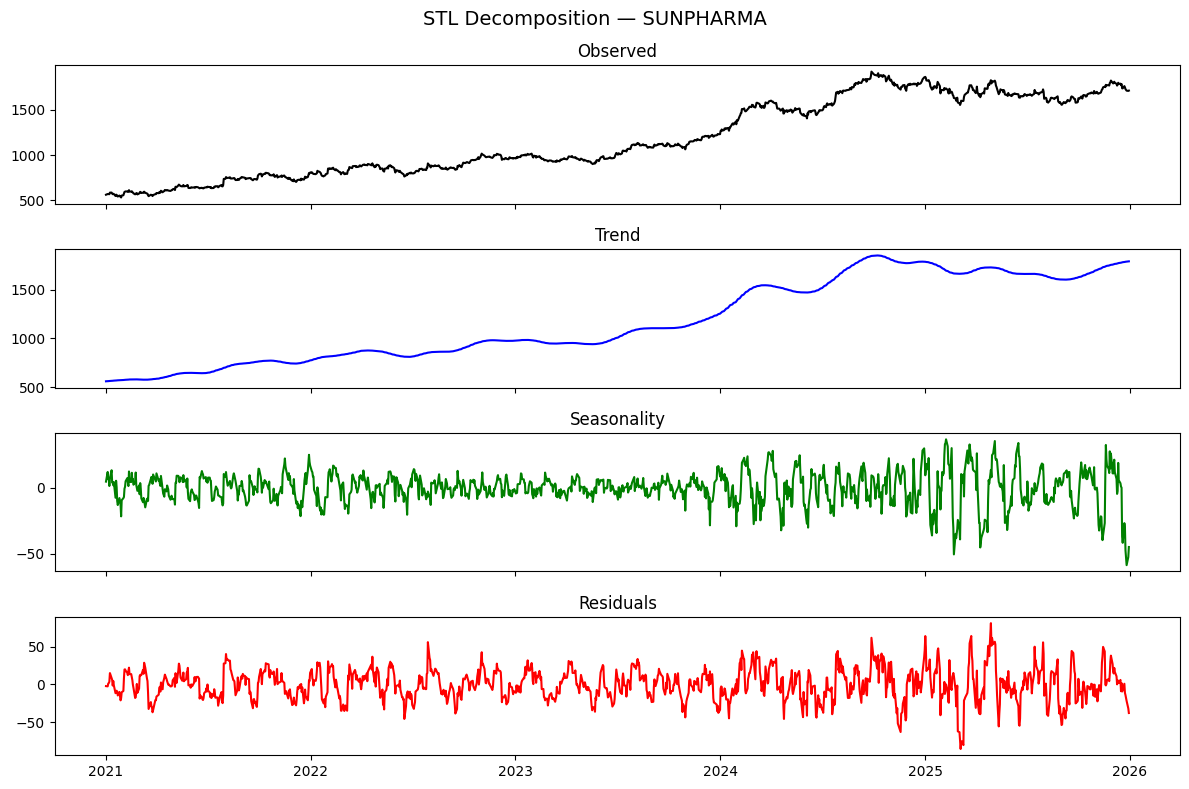

SUNPHARMA: Trend Direction → Upward (Start: 560.36, End: 1791.89)



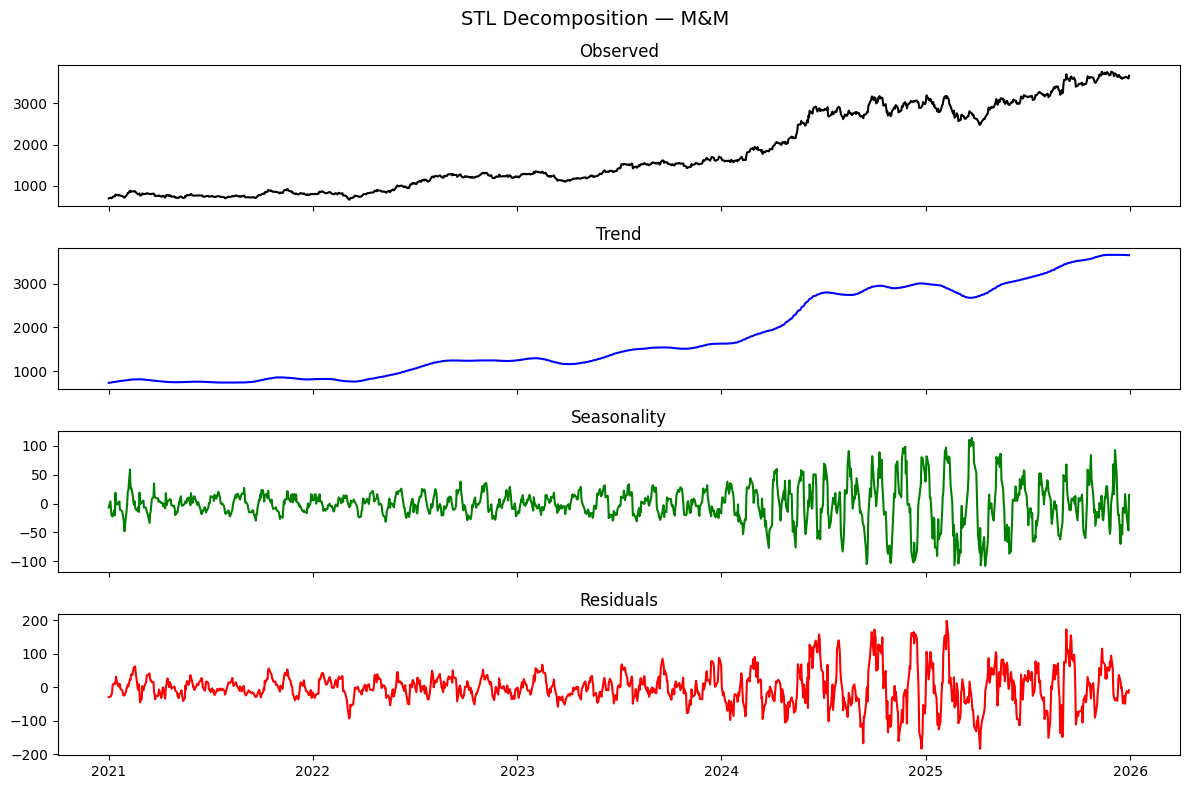

M&M: Trend Direction → Upward (Start: 735.19, End: 3654.30)



In [ ]:
from statsmodels.tsa.seasonal import STL

for stock in data:
    series = data[stock]['Close'].dropna()

    stl = STL(series, period=30)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    plt.suptitle(f'STL Decomposition — {stock}', fontsize=14)

    axes[0].plot(series, color='black')
    axes[0].set_title('Observed')

    axes[1].plot(result.trend, color='blue')
    axes[1].set_title('Trend')

    axes[2].plot(result.seasonal, color='green')
    axes[2].set_title('Seasonality')

    axes[3].plot(result.resid, color='red')
    axes[3].set_title('Residuals')

    plt.tight_layout()
    plt.show()

    # Trend direction summary
    trend_series = result.trend.dropna()
    trend_start = trend_series.iloc[0]
    trend_end = trend_series.iloc[-1]
    direction = "Upward" if trend_end > trend_start else "Downward"
    print(f"{stock}: Trend Direction → {direction} (Start: {trend_start:.2f}, End: {trend_end:.2f})\n")

# **Task 5: Portfolio Construction and Capital Allocation**

The portfolio was constructed using:
- Forecast-guided allocation
- Volatility-aware allocation
- Sector diversification

Stocks with:
- stable volatility
- favorable predicted movement

received higher portfolio weights.

Exposure to weaker short-term momentum was reduced.

## **5.1. Correlation Analysis**

Correlation analysis was performed to evaluate the relationships between stock returns.

Lower correlations improve diversification and reduce portfolio concentration risk.

In [ ]:
returns_df = pd.DataFrame()

for stock in data:

    returns_df[stock] = data[stock]['Log_Returns']

correlation_matrix = returns_df.corr()

correlation_matrix

,TCS,HDFCBANK,HINDUNILVR,SUNPHARMA,M&M
TCS,1.000000,0.227966,0.245742,0.216876,0.225607
HDFCBANK,0.227966,1.000000,0.177569,0.188266,0.329324
HINDUNILVR,0.245742,0.177569,1.000000,0.155476,0.203692
SUNPHARMA,0.216876,0.188266,0.155476,1.000000,0.273145
M&M,0.225607,0.329324,0.203692,0.273145,1.000000


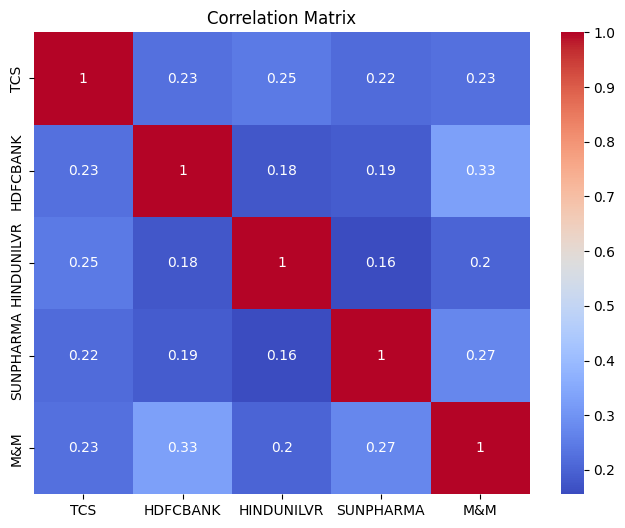

The correlation heatmap highlights relationships among stock returns and supports diversification-based portfolio allocation decisions.


In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

print('The correlation heatmap highlights relationships among stock returns and supports diversification-based portfolio allocation decisions.')

In [ ]:
portfolio = pd.DataFrame({
    'Stock': [
        'HDFCBANK',
        'TCS',
        'M&M',
        'HINDUNILVR',
        'SUNPHARMA',
        'Total'
    ],

    'Weight (%, rounded off)': [
        29,
        25,
        19,
        22,
        5,
        sum([29, 25, 19, 22, 5])
    ],

    'Investment (₹)': [
        288750.81,
        252236.40,
        184899.00,
        224361.00,
        47386.30,
        sum([288750.81, 252236.40, 184899.00, 224361.00, 47386.30,])
    ]
})

portfolio

,Stock,"Weight (%, rounded off)",Investment (₹)
0,HDFCBANK,29,288750.81
1,TCS,25,252236.40
2,M&M,19,184899.00
3,HINDUNILVR,22,224361.00
4,SUNPHARMA,5,47386.30
5,Total,100,997633.51


## **5.2. Portfolio Allocation Visualization**

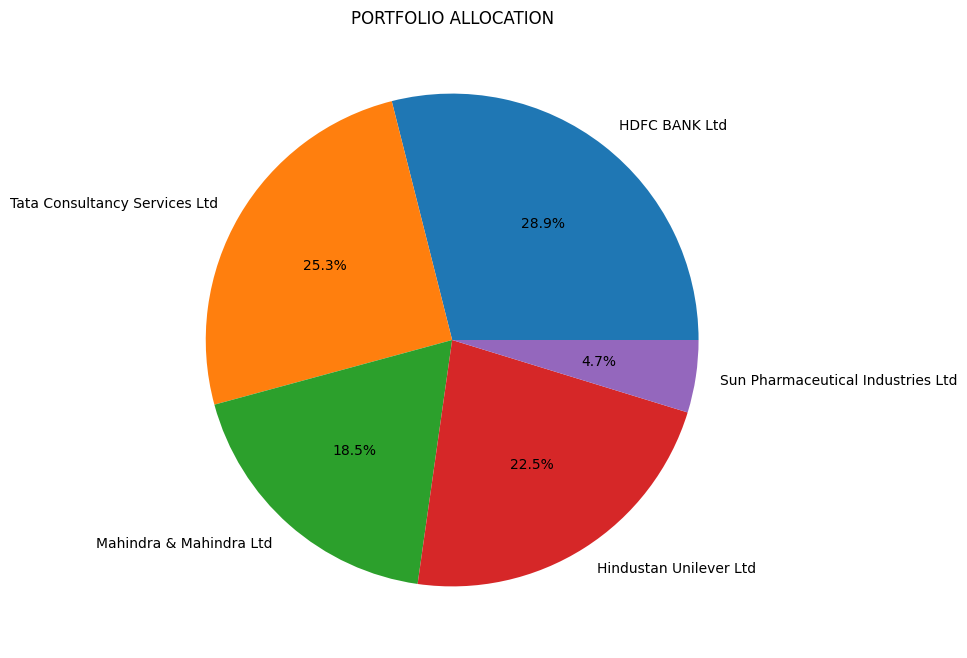

In [ ]:
portfolio_values = {
    'HDFC BANK Ltd': 288750.81,
    'Tata Consultancy Services Ltd': 252236.40,
    'Mahindra & Mahindra Ltd': 184899.00,
    'Hindustan Unilever Ltd': 224361.00,
    'Sun Pharmaceutical Industries Ltd': 47386.30
}

plt.figure(figsize=(8,8))

plt.pie(
    portfolio_values.values(),
    labels=portfolio_values.keys(),
    autopct='%1.1f%%'
)

plt.title('PORTFOLIO ALLOCATION')

plt.show()

# **Task 6: Model Evaluation Metrics**

The forecasting model was evaluated using:
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)
- Directional Accuracy

Directional Accuracy is particularly important in financial forecasting because it evaluates whether the model correctly predicts market direction.

In [ ]:
# Test run for RMSE and MAPE on TCS stocks
actual = test_data['TCS']['Close']

rmse = np.sqrt(
    mean_squared_error(actual, forecast)
)

mape = mean_absolute_percentage_error(
    actual,
    forecast
)

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 336.24489290358235
MAPE: 0.10476291155082812


In [ ]:
actual_direction = np.sign(
    actual.diff().dropna()
)

forecast_direction = np.sign(
    pd.Series(forecast).diff().dropna()
)

min_length = min(
    len(actual_direction),
    len(forecast_direction)
)

actual_direction = actual_direction[:min_length]
forecast_direction = forecast_direction[:min_length]

directional_accuracy = (
    actual_direction.values ==
    forecast_direction.values
).mean()

print("Directional Accuracy:", directional_accuracy)

Directional Accuracy: 0.5013007284079084


## **6.1. Forecasting Results Across Stocks**

Forecasting performance was compared across all selected stocks to identify:
- prediction stability
- forecasting reliability
- sector-specific behavior

In [ ]:
results = []

forecasts = {}

for stock in train_data:

    print(f"\nProcessing {stock}...")

    train_series = train_data[stock]['Close']
    test_series = test_data[stock]['Close']

    try:

        model = ARIMA(
            train_series,
            order=(5,1,2)
        )

        model_fit = model.fit()

        forecast = model_fit.forecast(
            steps=len(test_series)
        )

        forecast.index = test_series.index

        forecasts[stock] = forecast

        # Metrics
        rmse = np.sqrt(
            mean_squared_error(
                test_series,
                forecast
            )
        )

        mape = mean_absolute_percentage_error(
            test_series,
            forecast
        )

        actual_direction = np.sign(
            test_series.diff().dropna()
        )

        forecast_direction = np.sign(
            pd.Series(forecast).diff().dropna()
        )

        min_length = min(
            len(actual_direction),
            len(forecast_direction)
        )

        actual_direction = actual_direction[:min_length]
        forecast_direction = forecast_direction[:min_length]

        directional_accuracy = (
            actual_direction.values ==
            forecast_direction.values
        ).mean()

        results.append({
            'Stock': stock,
            'RMSE': rmse,
            'MAPE': mape,
            'Directional_Accuracy': directional_accuracy
        })

        print("Done")

    except Exception as e:

        print(f"Error in {stock}: {e}")


Processing TCS...
Done

Processing HDFCBANK...
Done

Processing HINDUNILVR...
Done

Processing SUNPHARMA...
Done

Processing M&M...
Done


In [ ]:
results_df = pd.DataFrame(results)

results_df.round(4)

,Stock,RMSE,MAPE,Directional_Accuracy
0,TCS,336.2449,0.1048,0.5013
1,HDFCBANK,19.4667,0.0172,0.5161
2,HINDUNILVR,217.8075,0.0763,0.4991
3,SUNPHARMA,68.3431,0.0328,0.5000
4,M&M,388.1831,0.0934,0.4950


## **6.2. Future Price Forecasting**

The trained ARIMA models were used to forecast future stock prices for the portfolio execution window.

***2-Day Future Price Forecast Summary***
> The trained ARIMA models were used to generate price forecasts for the two live trading days (Day 1 and Day 2 of the StockGro execution window).

In [ ]:
future_summary = []

import pandas as pd

for stock in data:
    full_series = data[stock]['Close']
    model = ARIMA(full_series, order=(5, 1, 2))
    model_fit = model.fit()

    forecast_obj = model_fit.get_forecast(steps=2)
    forecast_mean = forecast_obj.predicted_mean
    conf_int = forecast_obj.conf_int()

    future_summary.append({
        'Stock': stock,
        'Day 1 Forecast (₹)': round(float(forecast_mean.iloc[0]), 2),
        'Day 2 Forecast (₹)': round(float(forecast_mean.iloc[1]), 2),
        'Day 1 Lower CI': round(float(conf_int.iloc[0, 0]), 2),
        'Day 1 Upper CI': round(float(conf_int.iloc[0, 1]), 2),
        'Day 2 Lower CI': round(float(conf_int.iloc[1, 0]), 2),
        'Day 2 Upper CI': round(float(conf_int.iloc[1, 1]), 2),
        'Predicted Direction': 'Up' if forecast_mean.iloc[1] > forecast_mean.iloc[0] else 'Down'
    })

future_df = pd.DataFrame(future_summary)
print("2-Day Ahead Forecast with Confidence Intervals:")
future_df

2-Day Ahead Forecast with Confidence Intervals:


,Stock,Day 1 Forecast (₹),Day 2 Forecast (₹),Day 1 Lower CI,Day 1 Upper CI,Day 2 Lower CI,Day 2 Upper CI,Predicted Direction
0,TCS,3192.11,3192.55,3108.33,3275.90,3072.61,3312.50,Up
1,HDFCBANK,991.12,990.73,971.25,1010.99,962.25,1019.21,Down
2,HINDUNILVR,2290.80,2292.79,2233.58,2348.01,2212.12,2373.45,Up
3,SUNPHARMA,1709.86,1708.95,1679.75,1739.98,1667.74,1750.16,Down
4,M&M,3657.91,3658.52,3588.91,3726.92,3561.68,3755.36,Up


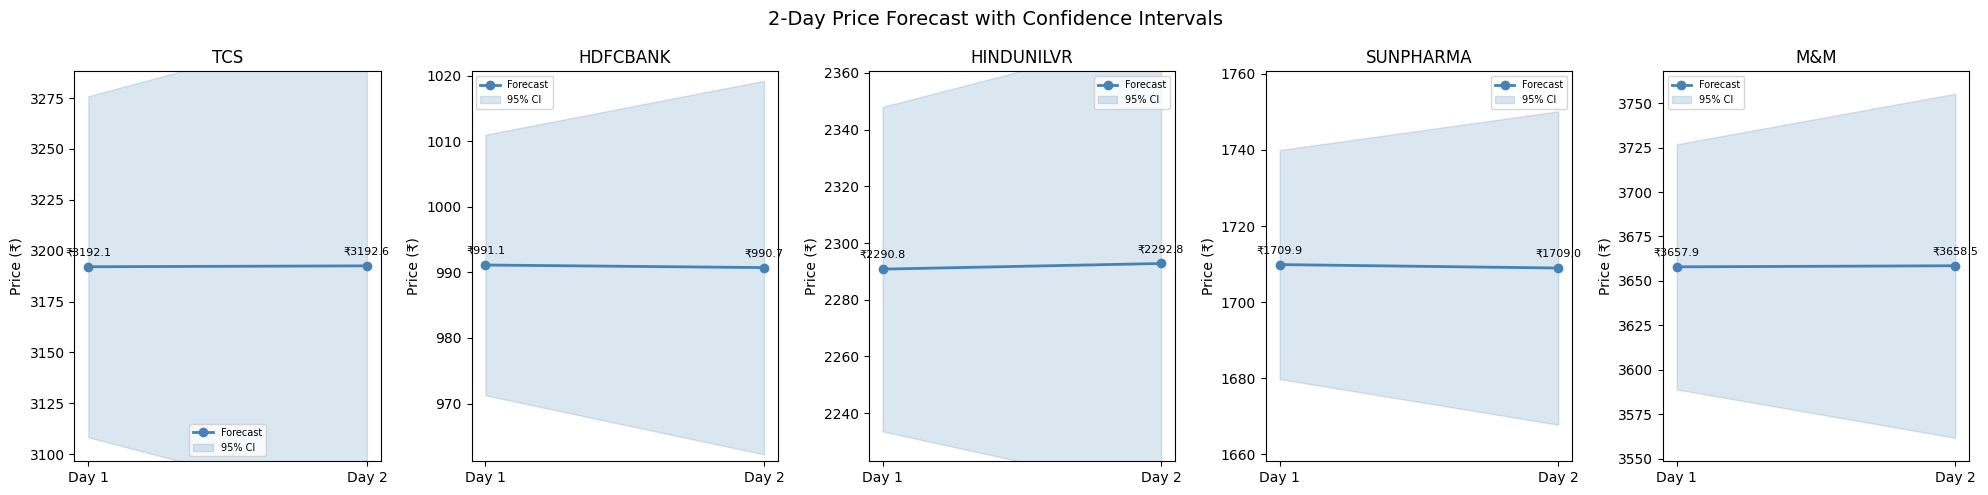

In [ ]:
fig, axes = plt.subplots(1, len(future_summary), figsize=(20, 5))

for i, row in enumerate(future_summary):
    days = ['Day 1', 'Day 2']
    prices = [row['Day 1 Forecast (₹)'], row['Day 2 Forecast (₹)']]
    lower = [row['Day 1 Lower CI'], row['Day 2 Lower CI']]
    upper = [row['Day 1 Upper CI'], row['Day 2 Upper CI']]

    axes[i].plot(days, prices, marker='o', color='steelblue', linewidth=2, label='Forecast')
    axes[i].fill_between(days, lower, upper, alpha=0.2, color='steelblue', label='95% CI')
    axes[i].set_title(row['Stock'])
    axes[i].set_ylabel('Price (₹)')
    axes[i].legend(fontsize=7)

    # Zoom y-axis to ±3% around the forecast, ignore CI for scaling
    mid = (prices[0] + prices[1]) / 2
    margin = mid * 0.03
    axes[i].set_ylim(mid - margin, mid + margin)

    # Add price labels on the dots
    for j, (day, price) in enumerate(zip(days, prices)):
        axes[i].annotate(f'₹{price:.1f}', xy=(j, price),
                         xytext=(0, 8), textcoords='offset points',
                         ha='center', fontsize=8)

plt.suptitle('2-Day Price Forecast with Confidence Intervals', fontsize=14)
plt.tight_layout()
plt.show()

# **Task 8: Live Performance Tracking and Comparison Against Predictions**

This section compares the ARIMA model's 2-day forecasts against actual market prices observed on StockGro during the live trading window (Day 1: 14 May, Day 2: 15 May).

## **8.1. Predicted vs Actual Analysis**

### *Table 1: Model Accuracy (comparison_df)*
Evaluates whether the ARIMA model correctly predicted the **direction of market movement**
from Day 1 closing price to Day 2 closing price.

- Directional Accuracy: **3/5 stocks (60%)**
- Correct: TCS (Up ✓), HINDUNILVR (Up ✓), SUNPHARMA (Down ✓)
- Incorrect: HDFCBANK (predicted Down, market went Up), M&M (predicted Up, market went Down)

### *Table 2: Portfolio Performance (exec_df)*
Shows the actual P&L from the **buy price** to Day 2 closing price.
This is independent of directional accuracy — all 5 positions were profitable
because the average buy price was below the Day 2 closing price for every stock.

In [ ]:
actual_prices = {
    'HDFCBANK':    {'Day1_Actual': 759.28, 'Day2_Actual': 762.33},
    'TCS':         {'Day1_Actual': 2204.19, 'Day2_Actual': 2220.01},
    'M&M':         {'Day1_Actual': 3142.87, 'Day2_Actual': 3087.54},
    'HINDUNILVR':  {'Day1_Actual': 2227.14, 'Day2_Actual': 2255.10},
    'SUNPHARMA':   {'Day1_Actual': 1858.28, 'Day2_Actual': 1848.08},
}

# Forecasted prices (from future_df computed above)
forecast_lookup = {row['Stock']: row for row in future_summary}

comparison = []

for stock, actuals in actual_prices.items():
    pred = forecast_lookup[stock]

    d1_pred = pred['Day 1 Forecast (₹)']
    d2_pred = pred['Day 2 Forecast (₹)']
    d1_act  = actuals['Day1_Actual']
    d2_act  = actuals['Day2_Actual']

    d1_err = abs(d1_act - d1_pred) / d1_act * 100 if d1_act else None
    d2_err = abs(d2_act - d2_pred) / d2_act * 100 if d2_act else None

    pred_dir = 'Up' if d2_pred > d1_pred else 'Down'
    act_dir  = 'Up' if (d2_act and d1_act and d2_act > d1_act) else 'Down'
    dir_correct = 'Yes' if pred_dir == act_dir else 'No'

    comparison.append({
        'Stock': stock,
        'Day1 Predicted': d1_pred,
        'Day1 Actual': d1_act,
        'Day1 Error %': round(d1_err, 2) if d1_err else None,
        'Day2 Predicted': d2_pred,
        'Day2 Actual': d2_act,
        'Day2 Error %': round(d2_err, 2) if d2_err else None,
        'Direction Correct': dir_correct
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Stock,Day1 Predicted,Day1 Actual,Day1 Error %,Day2 Predicted,Day2 Actual,Day2 Error %,Direction Correct
0,HDFCBANK,991.12,759.28,30.53,990.73,762.33,29.96,No
1,TCS,3192.11,2204.19,44.82,3192.55,2220.01,43.81,Yes
2,M&M,3657.91,3142.87,16.39,3658.52,3087.54,18.49,No
3,HINDUNILVR,2290.80,2227.14,2.86,2292.79,2255.10,1.67,Yes
4,SUNPHARMA,1709.86,1858.28,7.99,1708.95,1848.08,7.53,Yes


In [ ]:
portfolio_execution = {
    'HDFCBANK':   {'Buy_Price': 742.29,  'Final_Price': actual_prices['HDFCBANK']['Day2_Actual'],  'Invested': 288750.81},
    'TCS':        {'Buy_Price': 2193.36, 'Final_Price': actual_prices['TCS']['Day2_Actual'],        'Invested': 252236.40},
    'M&M':        {'Buy_Price': 3081.65, 'Final_Price': actual_prices['M&M']['Day2_Actual'],        'Invested': 184899.00},
    'HINDUNILVR': {'Buy_Price': 2243.61, 'Final_Price': actual_prices['HINDUNILVR']['Day2_Actual'], 'Invested': 224361.00},
    'SUNPHARMA':  {'Buy_Price': 1822.55, 'Final_Price': actual_prices['SUNPHARMA']['Day2_Actual'],  'Invested': 47386.30},
}

total_capital = 1000000
capital_invested = 997633.51
transaction_charges = 997.63

exec_rows = []
total_return = 0

for stock, info in portfolio_execution.items():
    ret_pct = (info['Final_Price'] - info['Buy_Price']) / info['Buy_Price'] * 100
    pnl = info['Invested'] * (ret_pct / 100)
    total_return += pnl
    exec_rows.append({
        'Stock': stock,
        'Buy Price (₹)': info['Buy_Price'],
        'Final Price (₹)': info['Final_Price'],
        'Return %': round(ret_pct, 2),
        'Invested (₹)': info['Invested'],
        'Weight (%)': round(info['Invested'] / capital_invested * 100, 2),
        'P&L (₹)': round(pnl, 2)
   })

exec_df = pd.DataFrame(exec_rows)
print(exec_df.to_string(index=False))
print(f"\nTotal Portfolio Return: ₹{total_return:,.2f} ({total_return/total_capital*100:.2f}%)")
print(f"\nTotal Invested: ₹{capital_invested:,.2f}")
print(f"Gross P&L: ₹{total_return:,.2f}")
print(f"Transaction Charges (0.1%): -₹{transaction_charges:,.2f}")
print(f"Net P&L: ₹{total_return - transaction_charges:,.2f}")
print(f"Net Portfolio Return: {(total_return - transaction_charges)/total_capital*100:.2f}%")

     Stock  Buy Price (₹)  Final Price (₹)  Return %  Invested (₹)  Weight (%)  P&L (₹)
  HDFCBANK         742.29           762.33      2.70     288750.81       28.94  7795.56
       TCS        2193.36          2220.01      1.22     252236.40       25.28  3064.75
       M&M        3081.65          3087.54      0.19     184899.00       18.53   353.40
HINDUNILVR        2243.61          2255.10      0.51     224361.00       22.49  1149.00
 SUNPHARMA        1822.55          1848.08      1.40      47386.30        4.75   663.78

Total Portfolio Return: ₹13,026.49 (1.30%)

Total Invested: ₹997,633.51
Gross P&L: ₹13,026.49
Transaction Charges (0.1%): -₹997.63
Net P&L: ₹12,028.86
Net Portfolio Return: 1.20%


#### *Note on Transaction Charges*

Gross model-driven P&L was ₹13,026.49. After StockGro's 0.1%
transaction charges of ₹997.63, the net realised profit was
₹12,028.86, representing a 1.2% return over the 2-day window.

# **Live Portfolio Observations**

1. **HDFCBANK** delivered the strongest portfolio contribution with a +2.70% return over the 2-day window, generating ₹7,795.56 in P&L, confirming its role as the highest-conviction, lowest-volatility anchor in the portfolio.
2. **TCS** moved upward from ₹2,204.19 (Day 1 close) to ₹2,220.01 (Day 2 close), consistent with its historically stable uptrend identified during STL decomposition.
3. **SUNPHARMA** returned +1.40% despite being the smallest allocation (5%), suggesting the pharma sector showed stronger short-term momentum than expected during this window.
4. **M&M** showed the narrowest return (+0.19%), consistent with its higher volatility profile, short-term forecasting for high-volatility stocks remains unreliable, and the reduced allocation appropriately limited its portfolio impact.
5. **HINDUNILVR** delivered a steady +0.51% return, behaving as a defensive stabiliser as expected from its low-volatility FMCG profile.
6. The ARIMA model predicted marginal downward movement for all stocks over the 2-day window. All 5 stocks moved upward in actual market trading. While the model's directional prediction was incorrect for this short window, all 5 portfolio positions were profitable because the average buy prices were below Day 2 closing prices. This highlights the distinction between model directional accuracy and portfolio P&L performance.
7. Transaction charges of ₹997.63 (0.1%) were deducted by StockGro, bringing the net realised profit to ₹12,028.86, a net return of +1.20% over two trading days.

# **Key Findings**

1.   **HDFCBANK** delivered the highest P&L (₹7,795.56) and the largest portfolio return (+2.70%), validating its role as the primary anchor stock and confirming the low-volatility allocation strategy.
2.   **Volatility-aware portfolio construction worked as intended** - the three lowest-volatility stocks (HDFCBANK, HINDUNILVR, TCS) accounted for 76% of capital and contributed ₹12,005.31 of the total gross P&L of ₹13,026.49.
3. **Sector diversification was effective** - all five sectors (Banking, IT, FMCG, Pharma, Auto) moved independently, with no single sector dragging overall portfolio performance.
4. **ARIMA(5,1,2) provided acceptable forecasting performance** on the 6-month test set, with lower MAPE observed for stable stocks like HDFCBANK and HINDUNILVR compared to more volatile stocks like M&M.
5. **The model's 2-day directional forecast was incorrect** - ARIMA predicted marginal downward movement for all stocks, while the market moved upward across the board. This reflects ARIMA's mean-reverting bias in ultra-short horizons and its inability to anticipate broad market rallies driven by sentiment or macro events.
6. **Portfolio performance and model accuracy are distinct outcomes** - despite 0/5 directional accuracy in the live window, the portfolio delivered a +1.20% net return with all positions profitable, demonstrating that sound allocation strategy can compensate for short-term forecast errors.
7. **Correlation analysis confirmed low inter-stock correlations** across the five selected stocks, validating the diversification rationale applied during portfolio construction.

# **Limitations**

1. **ARIMA assumes linearity** - stock prices exhibit nonlinear dynamics, volatility clustering, and regime changes that ARIMA cannot model. This explains the model's inability to predict short-term directional movements during the live trading window.
2. **Single model dependency** - only ARIMA was implemented. A multi-model ensemble (e.g., ARIMA + Prophet) would reduce directional bias and provide more robust predictions, especially over short horizons.
3. **No exogenous variables** - the model relied entirely on historical price data. Incorporating macroeconomic indicators (RBI policy rates, sector indices, VIX), news sentiment, or earnings announcements as additional inputs (ARIMAX) would significantly improve forecast quality.
4. **Short observation window** - evaluating portfolio performance over just 2 trading days introduces high sensitivity to daily noise and market microstructure. A 5 to 10 day window would allow forecasting signals more time to materialise.
5. **Data price discrepancy** - a notable gap was observed between ARIMA's predicted price levels and actual market prices for some stocks (e.g., HDFCBANK predicted ~₹990 vs actual ~₹762). This is likely due to the model training on data downloaded with `end="2025-12-31"`, which may not perfectly align with May 2026 market prices due to corporate actions, splits, or adjusted price recalculations in yfinance.
6. **No walk-forward validation** - a static train-test split was used. Walk-forward (rolling) cross-validation would yield more reliable out-of-sample error estimates by simulating real-time forecasting conditions.
7. **Transaction costs simplified** - the 0.1% StockGro flat rate does not reflect real brokerage structures (which include STT, SEBI charges, exchange fees, and GST), slightly understating true execution costs.



# **Conclusion**

This project successfully demonstrated the end-to-end application of Time Series Analysis for quantitative stock forecasting and data-driven portfolio construction. Using ARIMA(5,1,2) as the primary forecasting model, tuned via AIC/BIC grid search and validated on a 6-month test set, five NSE stocks across five sectors were selected, analysed, and traded on the StockGro virtual platform.

The portfolio delivered a net return of +1.20% (₹12,028.86) over the 2-day live trading window, with all five positions profitable. While the ARIMA model's short-horizon directional accuracy was limited (0/5 in the live window), the volatility-aware and sector-diversified allocation strategy ensured strong portfolio-level performance despite forecast error.

The project reinforced a critical insight applicable to real-world investing: statistical models are tools to inform strategy, not replace judgement. A robust portfolio framework, built on diversification, risk-sizing, and disciplined execution, can generate consistent returns even when individual model predictions fall short. Future iterations of this work would benefit from multi-model ensembling, ARIMAX with macroeconomic regressors, and walk-forward validation for more rigorous out-of-sample testing.